In [15]:
import os
import sys
import cv2
import rawpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.preprocessing import PolynomialFeatures

# ==========================================
# 1. KONFIGURASI PATH UNTUK 1 DATA UJI
# ==========================================
# Sesuaikan Jalur Utama agar bisa import ColorCorrectionML
JALUR_UTAMA = r'C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA'
if JALUR_UTAMA not in sys.path:
    sys.path.append(JALUR_UTAMA)

try:
    from scripts.ColorCorrectionML import ColorCorrectionML
except ImportError:
    print(f"Error: Modul ColorCorrectionML tidak ditemukan di {JALUR_UTAMA}")

# Tentukan SATU set gambar yang ingin diuji (Misal: Subj_1, Samsung A52s, Mata Kiri)
PATH_GAMBAR_TARGET = r"C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Hasil Pengambilan Data\Hasil Gambar\Subj_3\iPhone 11\right.dng"
PATH_GAMBAR_CC = r"C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Hasil Pengambilan Data\Hasil Gambar\Subj_3\iPhone 11\cc.dng"
PATH_MASK = r"C:\Folder Dzakwan\Folder Dzakwan\Keperluan TA\dataset\Hasil Pengambilan Data\Ground Truth\Subj_3\iPhone 11\right.png" # Sesuaikan .png / .jpg

In [16]:
def ambil_gambar_raw(dng_path):
    with rawpy.imread(dng_path) as raw:
        rgb_image = raw.postprocess(use_camera_wb=True, exp_shift=1.0)
    return rgb_image

In [12]:
def roi_cropping(image_rgb, mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image_rgb, mask
    
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    
    padding = 10
    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(image_rgb.shape[1], x + w + padding)
    y2 = min(image_rgb.shape[0], y + h + padding)
    
    cropped_img = image_rgb[y1:y2, x1:x2]
    cropped_mask = mask[y1:y2, x1:x2]
    return cropped_img, cropped_mask

def restoration(image_rgb, mask):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    _, bright_mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
    bright_mask_in_eye = cv2.bitwise_and(bright_mask, mask)
    
    img_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    inpainted_bgr = cv2.inpaint(img_bgr, bright_mask_in_eye, inpaintRadius=8, flags=cv2.INPAINT_NS)
    inpainted_rgb = cv2.cvtColor(inpainted_bgr, cv2.COLOR_BGR2RGB)
    return inpainted_rgb, bright_mask_in_eye

In [13]:
def color_correction(target_img, cc_img):
    bgr_cc = cv2.cvtColor(cc_img, cv2.COLOR_RGB2BGR)
    cc_ml = ColorCorrectionML(bgr_cc, chart='Classic', illuminant='D50')
    src_awal, _, _ = cc_ml.extract_color_chart()

    degree = 3
    model_pls, _ = cc_ml.compute_correction(show=False, method='pls', degree=degree, interactions_only=False, ncomp=10)
    poly = PolynomialFeatures(degree=degree, interaction_only=False)
    
    img = target_img.copy() 
    h, w, c = img.shape
    img_flat = img.reshape(-1, 3)

    poly.fit(img_flat[:1])
    img_corrected_flat = np.zeros_like(img_flat, dtype=np.float32)
    chunk_size = 1_000_000

    for i in range(0, len(img_flat), chunk_size):
        chunk = img_flat[i:i+chunk_size].astype(np.float32)
        chunk_poly = poly.transform(chunk)
        img_corrected_flat[i:i+chunk_size] = model_pls.predict(chunk_poly)

    corrected_img = np.clip(img_corrected_flat, 0, 255).astype(np.uint8).reshape(h, w, c)
    return corrected_img

In [14]:
def extract_features(image_rgb, mask):
    features = {}
    valid_pixels = mask == 255
    channels = {}
    
    r, g, b = cv2.split(image_rgb)
    channels.update({'R': r, 'G': g, 'B': b})
    
    hsv_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv_image)
    channels.update({'H': h, 'S': s, 'V': v})
    
    lab_image = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)
    l, a, b_lab = cv2.split(lab_image)
    channels.update({'L': l, 'A': a, 'B_lab': b_lab})
    
    for channel_name, channel_data in channels.items():
        pixel_values = channel_data[valid_pixels]
        if len(pixel_values) > 0:
            features[f'{channel_name}_Mean'] = np.mean(pixel_values)
            features[f'{channel_name}_Std'] = np.std(pixel_values)
            features[f'{channel_name}_Skew'] = skew(pixel_values) if len(pixel_values) > 2 else 0
    return features

In [17]:
# 1. Ambil Gambar
img_ori = ambil_gambar_raw(PATH_GAMBAR_TARGET)
cc_ori = ambil_gambar_raw(PATH_GAMBAR_CC)

# Load Mask
mask_ori = cv2.imread(PATH_MASK, cv2.IMREAD_GRAYSCALE)
_, mask_ori = cv2.threshold(mask_ori, 127, 255, cv2.THRESH_BINARY)
if mask_ori.shape != img_ori.shape[:2]:
    mask_ori = cv2.resize(mask_ori, (img_ori.shape[1], img_ori.shape[0]), interpolation=cv2.INTER_NEAREST)

## Color Correction -> Cropping

In [18]:
print("2. Memproses Color Correction pada gambar RAW (Mungkin butuh waktu beberapa detik)...")
corrected_img_full = color_correction(img_ori, cc_ori)

print("3. Memproses ROI Cropping...")
# Crop dilakukan pada gambar yang SUDAH dikoreksi warnanya
roi_img, roi_mask = roi_cropping(corrected_img_full, mask_ori)

print("4. Memproses Brightspot Denoising (Restoration)...")
# Restoration dilakukan pada ROI yang sudah di-crop
restored_img, bright_mask_visual = restoration(roi_img, roi_mask)

print("5. Mengekstrak Fitur...")
# Ekstraksi fitur diambil dari hasil akhir restoration
hasil_fitur = extract_features(restored_img, roi_mask)

2. Memproses Color Correction pada gambar RAW (Mungkin butuh waktu beberapa detik)...
Initial mean DeltaE:  4.25788982458
Number of components:  10
3. Memproses ROI Cropping...
4. Memproses Brightspot Denoising (Restoration)...
5. Mengekstrak Fitur...


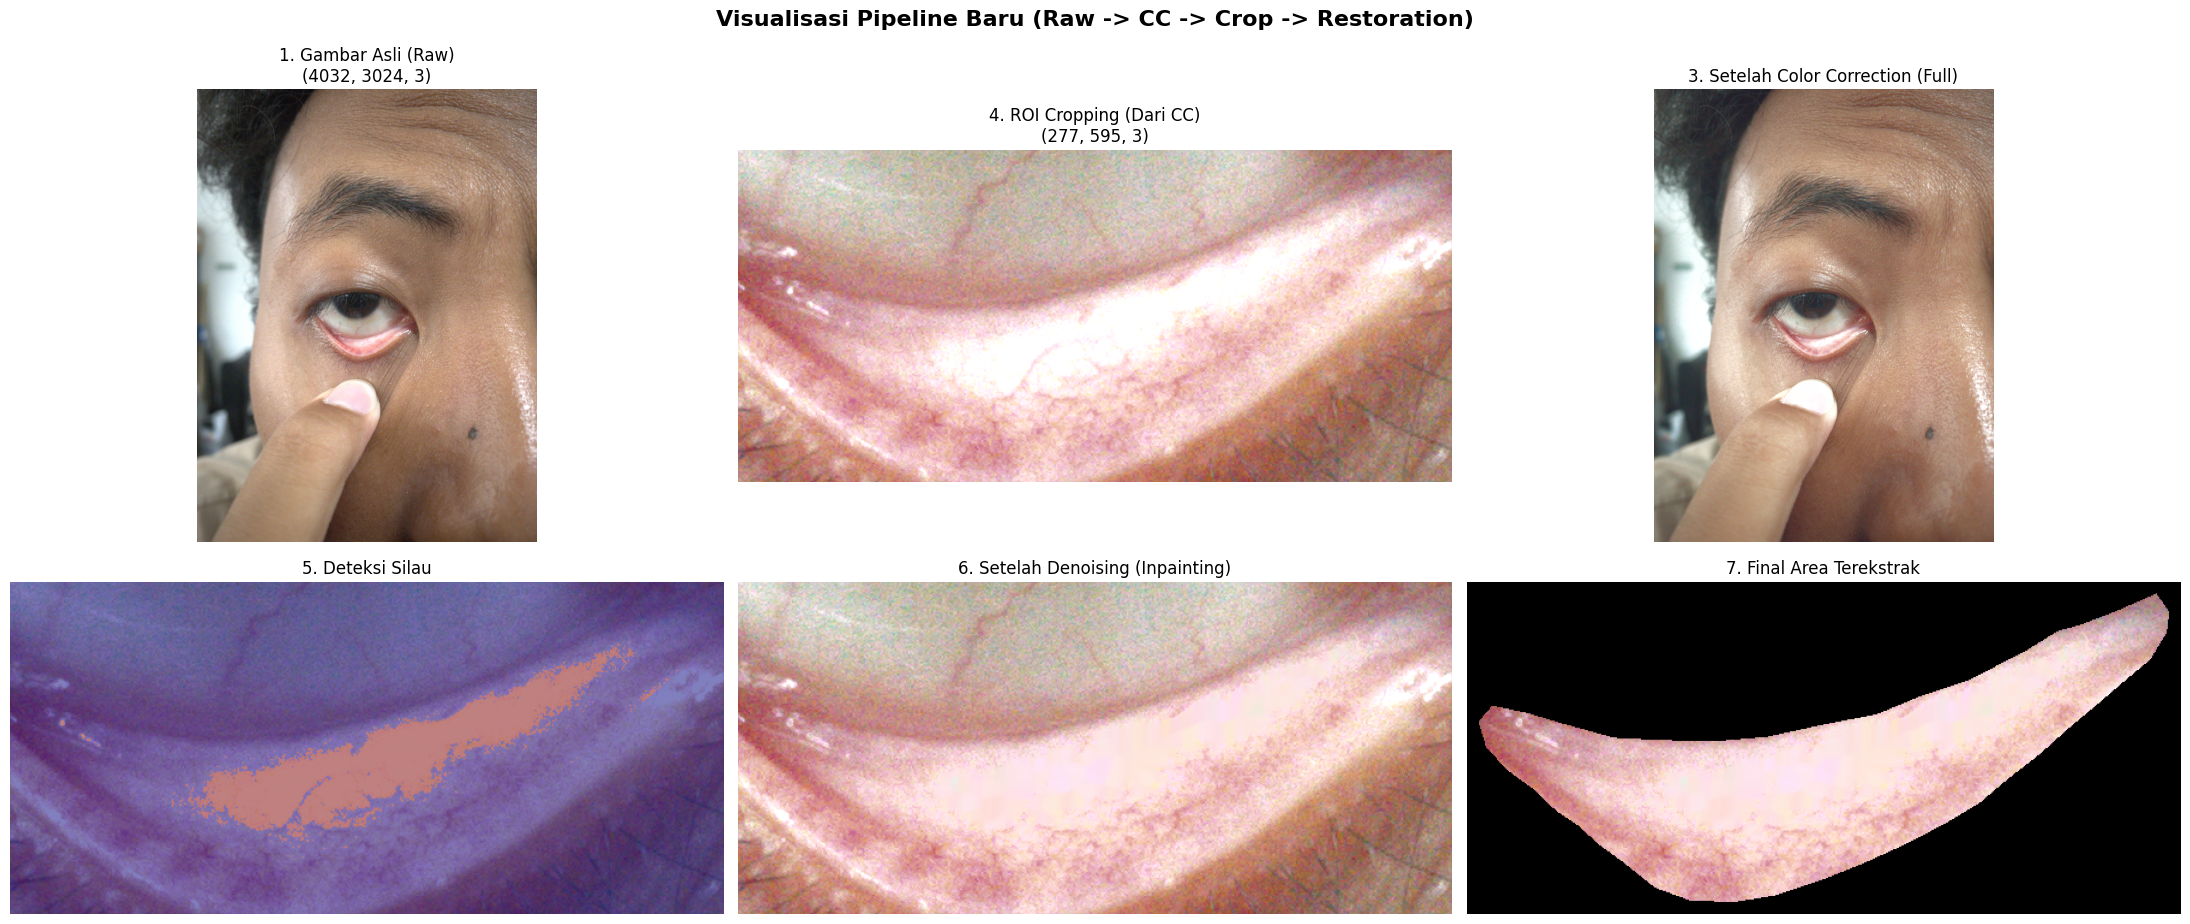


HASIL EKSTRAKSI FITUR (27 FITUR WARNA)
R_Mean         : 239.5722
R_Std          : 18.8780
R_Skew         : -1.5617
G_Mean         : 198.4097
G_Std          : 32.1491
G_Skew         : -1.0381
B_Mean         : 196.9885
B_Std          : 32.3260
B_Skew         : -0.8652
H_Mean         : 77.5039
H_Std          : 83.1166
H_Skew         : 0.2919
S_Mean         : 50.7441
S_Std          : 23.0139
S_Skew         : 1.0730
V_Mean         : 239.5804
V_Std          : 18.8573
V_Skew         : -1.5572
L_Mean         : 212.9817
L_Std          : 25.8102
L_Skew         : -1.0995
A_Mean         : 142.6067
A_Std          : 7.2335
A_Skew         : 0.8941
B_lab_Mean     : 134.4165
B_lab_Std      : 6.1103
B_lab_Skew     : 0.5102


In [19]:
fig, axes = plt.subplots(2, 3, figsize=(22, 10))
fig.suptitle("Visualisasi Pipeline Baru (Raw -> CC -> Crop -> Restoration)", fontsize=16, fontweight='bold')

# Plot 1: Gambar Asli
axes[0, 0].imshow(img_ori)
axes[0, 0].set_title(f"1. Gambar Asli (Raw)\n{img_ori.shape}")
axes[0, 0].axis('off')

# Plot 3: Gambar Full Corrected
axes[0, 2].imshow(corrected_img_full)
axes[0, 2].set_title("3. Setelah Color Correction (Full)")
axes[0, 2].axis('off')

# Plot 4: ROI Cropped
axes[0, 1].imshow(roi_img)
axes[0, 1].set_title(f"4. ROI Cropping (Dari CC)\n{roi_img.shape}")
axes[0, 1].axis('off')

# Plot 5: Brightspot Mask
axes[1, 0].imshow(roi_img)
axes[1, 0].imshow(bright_mask_visual, cmap='jet', alpha=0.5) 
axes[1, 0].set_title("5. Deteksi Silau")
axes[1, 0].axis('off')

# Plot 6: Restored Image
axes[1, 1].imshow(restored_img)
axes[1, 1].set_title("6. Setelah Denoising (Inpainting)")
axes[1, 1].axis('off')

# Plot 7: Mask Applied & Fitur
final_masked = cv2.bitwise_and(restored_img, restored_img, mask=roi_mask)
axes[1, 2].imshow(final_masked)
axes[1, 2].set_title("7. Final Area Terekstrak")
axes[1, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Print Hasil Fitur
print("\n" + "="*40)
print("HASIL EKSTRAKSI FITUR (27 FITUR WARNA)")
print("="*40)
for key, value in hasil_fitur.items():
    print(f"{key:<15}: {value:.4f}")

## Cropping -> Color Correction

In [20]:
print("Memproses ROI Cropping...")
# 2. ROI Cropping
roi_img, roi_mask = roi_cropping(img_ori, mask_ori)

print("Memproses Brightspot Denoising...")
# 3. Restoration (Brightspot Denoising)
restored_img, bright_mask_visual = restoration(roi_img, roi_mask)

print("Memproses Color Correction (Melatih model PLS)...")
# 4. Color Correction
corrected_img = color_correction(restored_img, cc_ori)

print("Mengekstrak Fitur...")
# 5. Ekstraksi Fitur
hasil_fitur = extract_features(corrected_img, roi_mask)

Memproses ROI Cropping...
Memproses Brightspot Denoising...
Memproses Color Correction (Melatih model PLS)...
Initial mean DeltaE:  4.25788982458
Number of components:  10
Mengekstrak Fitur...


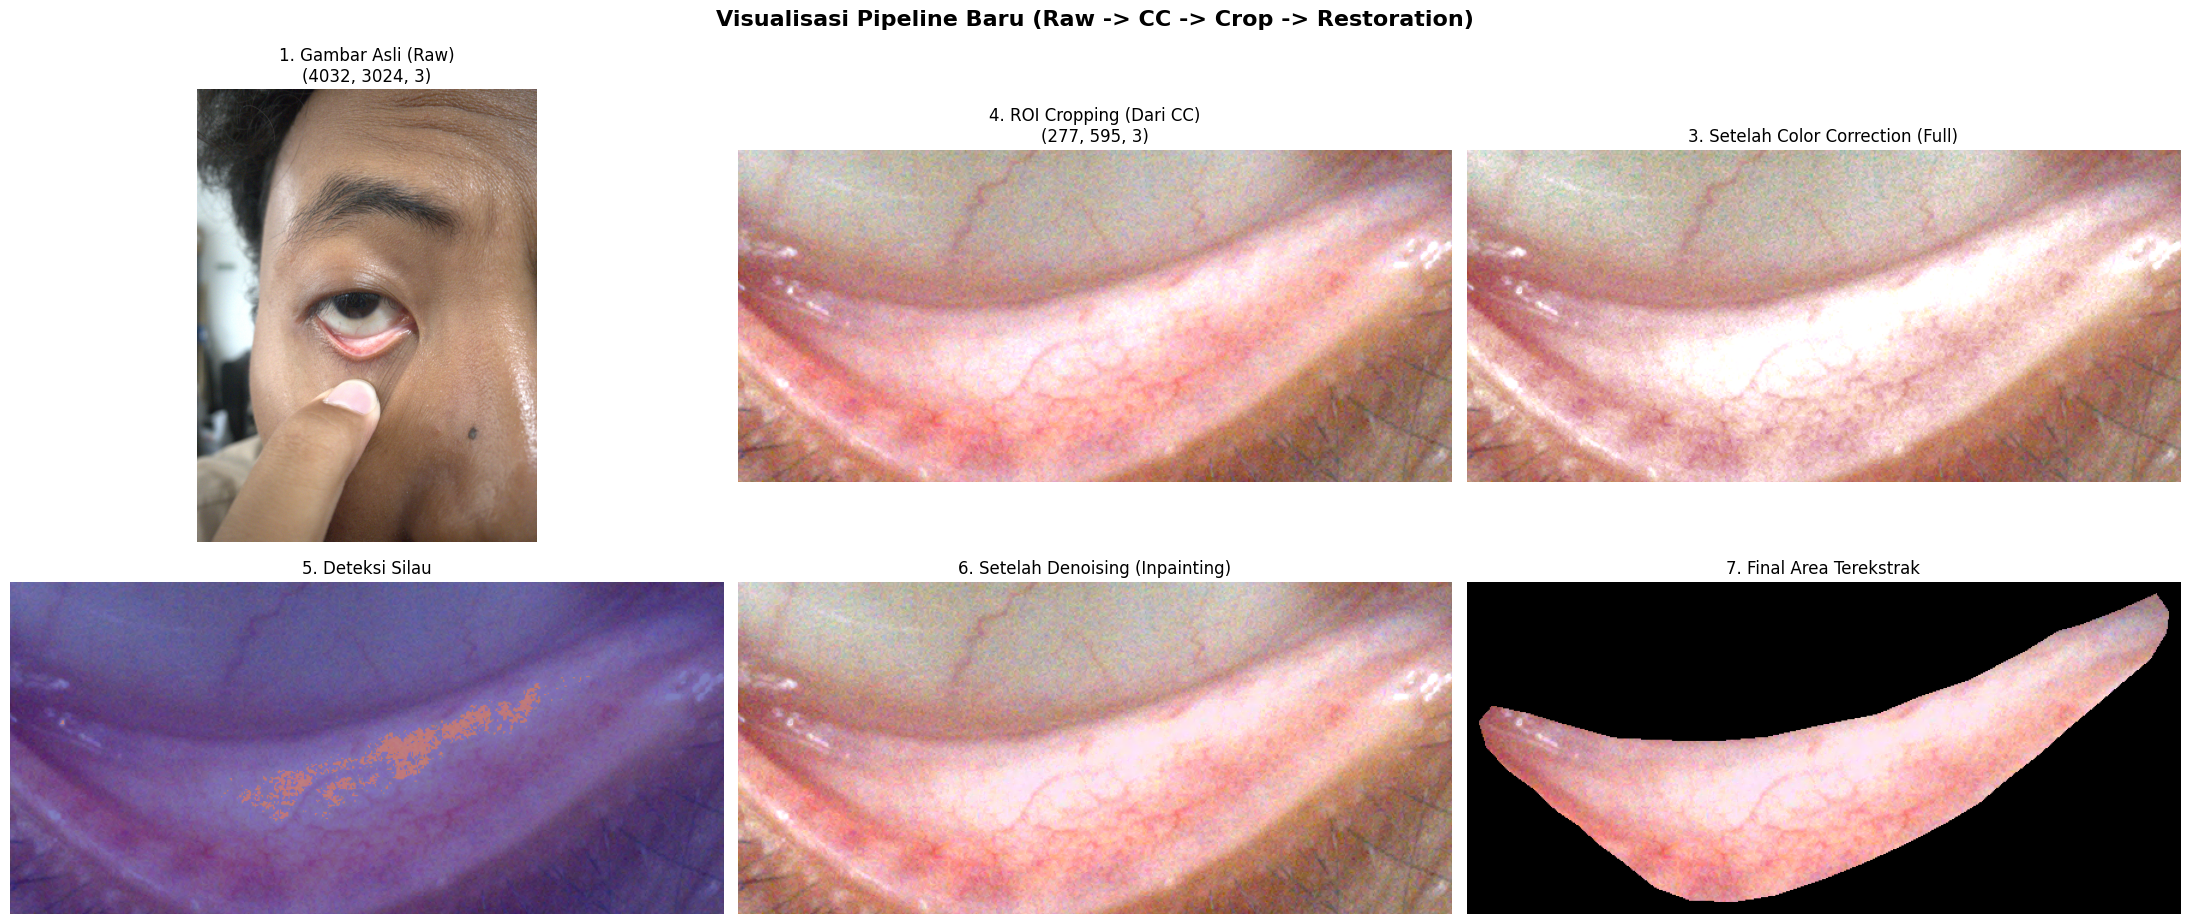


HASIL EKSTRAKSI FITUR (27 FITUR WARNA)
R_Mean         : 239.9957
R_Std          : 19.1704
R_Skew         : -1.5236
G_Mean         : 204.5629
G_Std          : 38.8395
G_Skew         : -0.5004
B_Mean         : 203.0696
B_Std          : 38.9359
B_Skew         : -0.3998
H_Mean         : 66.6262
H_Std          : 80.2081
H_Skew         : 0.5525
S_Mean         : 44.6351
S_Std          : 30.1610
S_Skew         : 0.2591
V_Mean         : 240.0035
V_Std          : 19.1500
V_Skew         : -1.5192
L_Mean         : 217.2666
L_Std          : 30.3166
L_Skew         : -0.6284
A_Mean         : 140.6241
A_Std          : 9.3495
A_Skew         : 0.2900
B_lab_Mean     : 133.7269
B_lab_Std      : 6.4241
B_lab_Skew     : 0.6526


In [21]:
fig, axes = plt.subplots(2, 3, figsize=(22, 10))
fig.suptitle("Visualisasi Pipeline Baru (Raw -> CC -> Crop -> Restoration)", fontsize=16, fontweight='bold')

# Plot 1: Gambar Asli
axes[0, 0].imshow(img_ori)
axes[0, 0].set_title(f"1. Gambar Asli (Raw)\n{img_ori.shape}")
axes[0, 0].axis('off')

# Plot 3: Gambar Full Corrected
axes[0, 2].imshow(corrected_img)
axes[0, 2].set_title("3. Setelah Color Correction (Full)")
axes[0, 2].axis('off')

# Plot 4: ROI Cropped
axes[0, 1].imshow(roi_img)
axes[0, 1].set_title(f"4. ROI Cropping (Dari CC)\n{roi_img.shape}")
axes[0, 1].axis('off')

# Plot 5: Brightspot Mask
axes[1, 0].imshow(roi_img)
axes[1, 0].imshow(bright_mask_visual, cmap='jet', alpha=0.5) 
axes[1, 0].set_title("5. Deteksi Silau")
axes[1, 0].axis('off')

# Plot 6: Restored Image
axes[1, 1].imshow(restored_img)
axes[1, 1].set_title("6. Setelah Denoising (Inpainting)")
axes[1, 1].axis('off')

# Plot 7: Mask Applied & Fitur
final_masked = cv2.bitwise_and(restored_img, restored_img, mask=roi_mask)
axes[1, 2].imshow(final_masked)
axes[1, 2].set_title("7. Final Area Terekstrak")
axes[1, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Print Hasil Fitur
print("\n" + "="*40)
print("HASIL EKSTRAKSI FITUR (27 FITUR WARNA)")
print("="*40)
for key, value in hasil_fitur.items():
    print(f"{key:<15}: {value:.4f}")